## Chapter 4

### Question 13

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis as LDA,
    QuadraticDiscriminantAnalysis as QDA
)
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

An initial examination of the dataset show that it contains 9 columns, with all except 'direction' column consisting of numerical values.

In [242]:
# Load data
weekly = pd.read_csv('data/Weekly.csv')

# Adapt column names
weekly.columns = [x.lower() for x in weekly.columns]

In [243]:
# Check basic info
weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       1089 non-null   int64  
 1   lag1       1089 non-null   float64
 2   lag2       1089 non-null   float64
 3   lag3       1089 non-null   float64
 4   lag4       1089 non-null   float64
 5   lag5       1089 non-null   float64
 6   volume     1089 non-null   float64
 7   today      1089 non-null   float64
 8   direction  1089 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 76.7+ KB


In [244]:
# Check a few observations
weekly.head()

,year,lag1,lag2,lag3,lag4,lag5,volume,today,direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


#### 13a)

Based on the information below, we observe that, on average, weekly returns are more often positive than negative. The mean values of all 'lag' variables, as well as 'today', are small but positive. Additionally, there are more 'Up' observations in the 'direction' variable.

When examining the plots, most variables appear random, except for 'volume' vs 'year', which shows a growth pattern throughout the recorded period.

In [245]:
weekly.describe()

,year,lag1,lag2,lag3,lag4,lag5,volume,today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [246]:
# Get 'direction' description
weekly['direction'].describe()

count     1089
unique       2
top         Up
freq       605
Name: direction, dtype: object

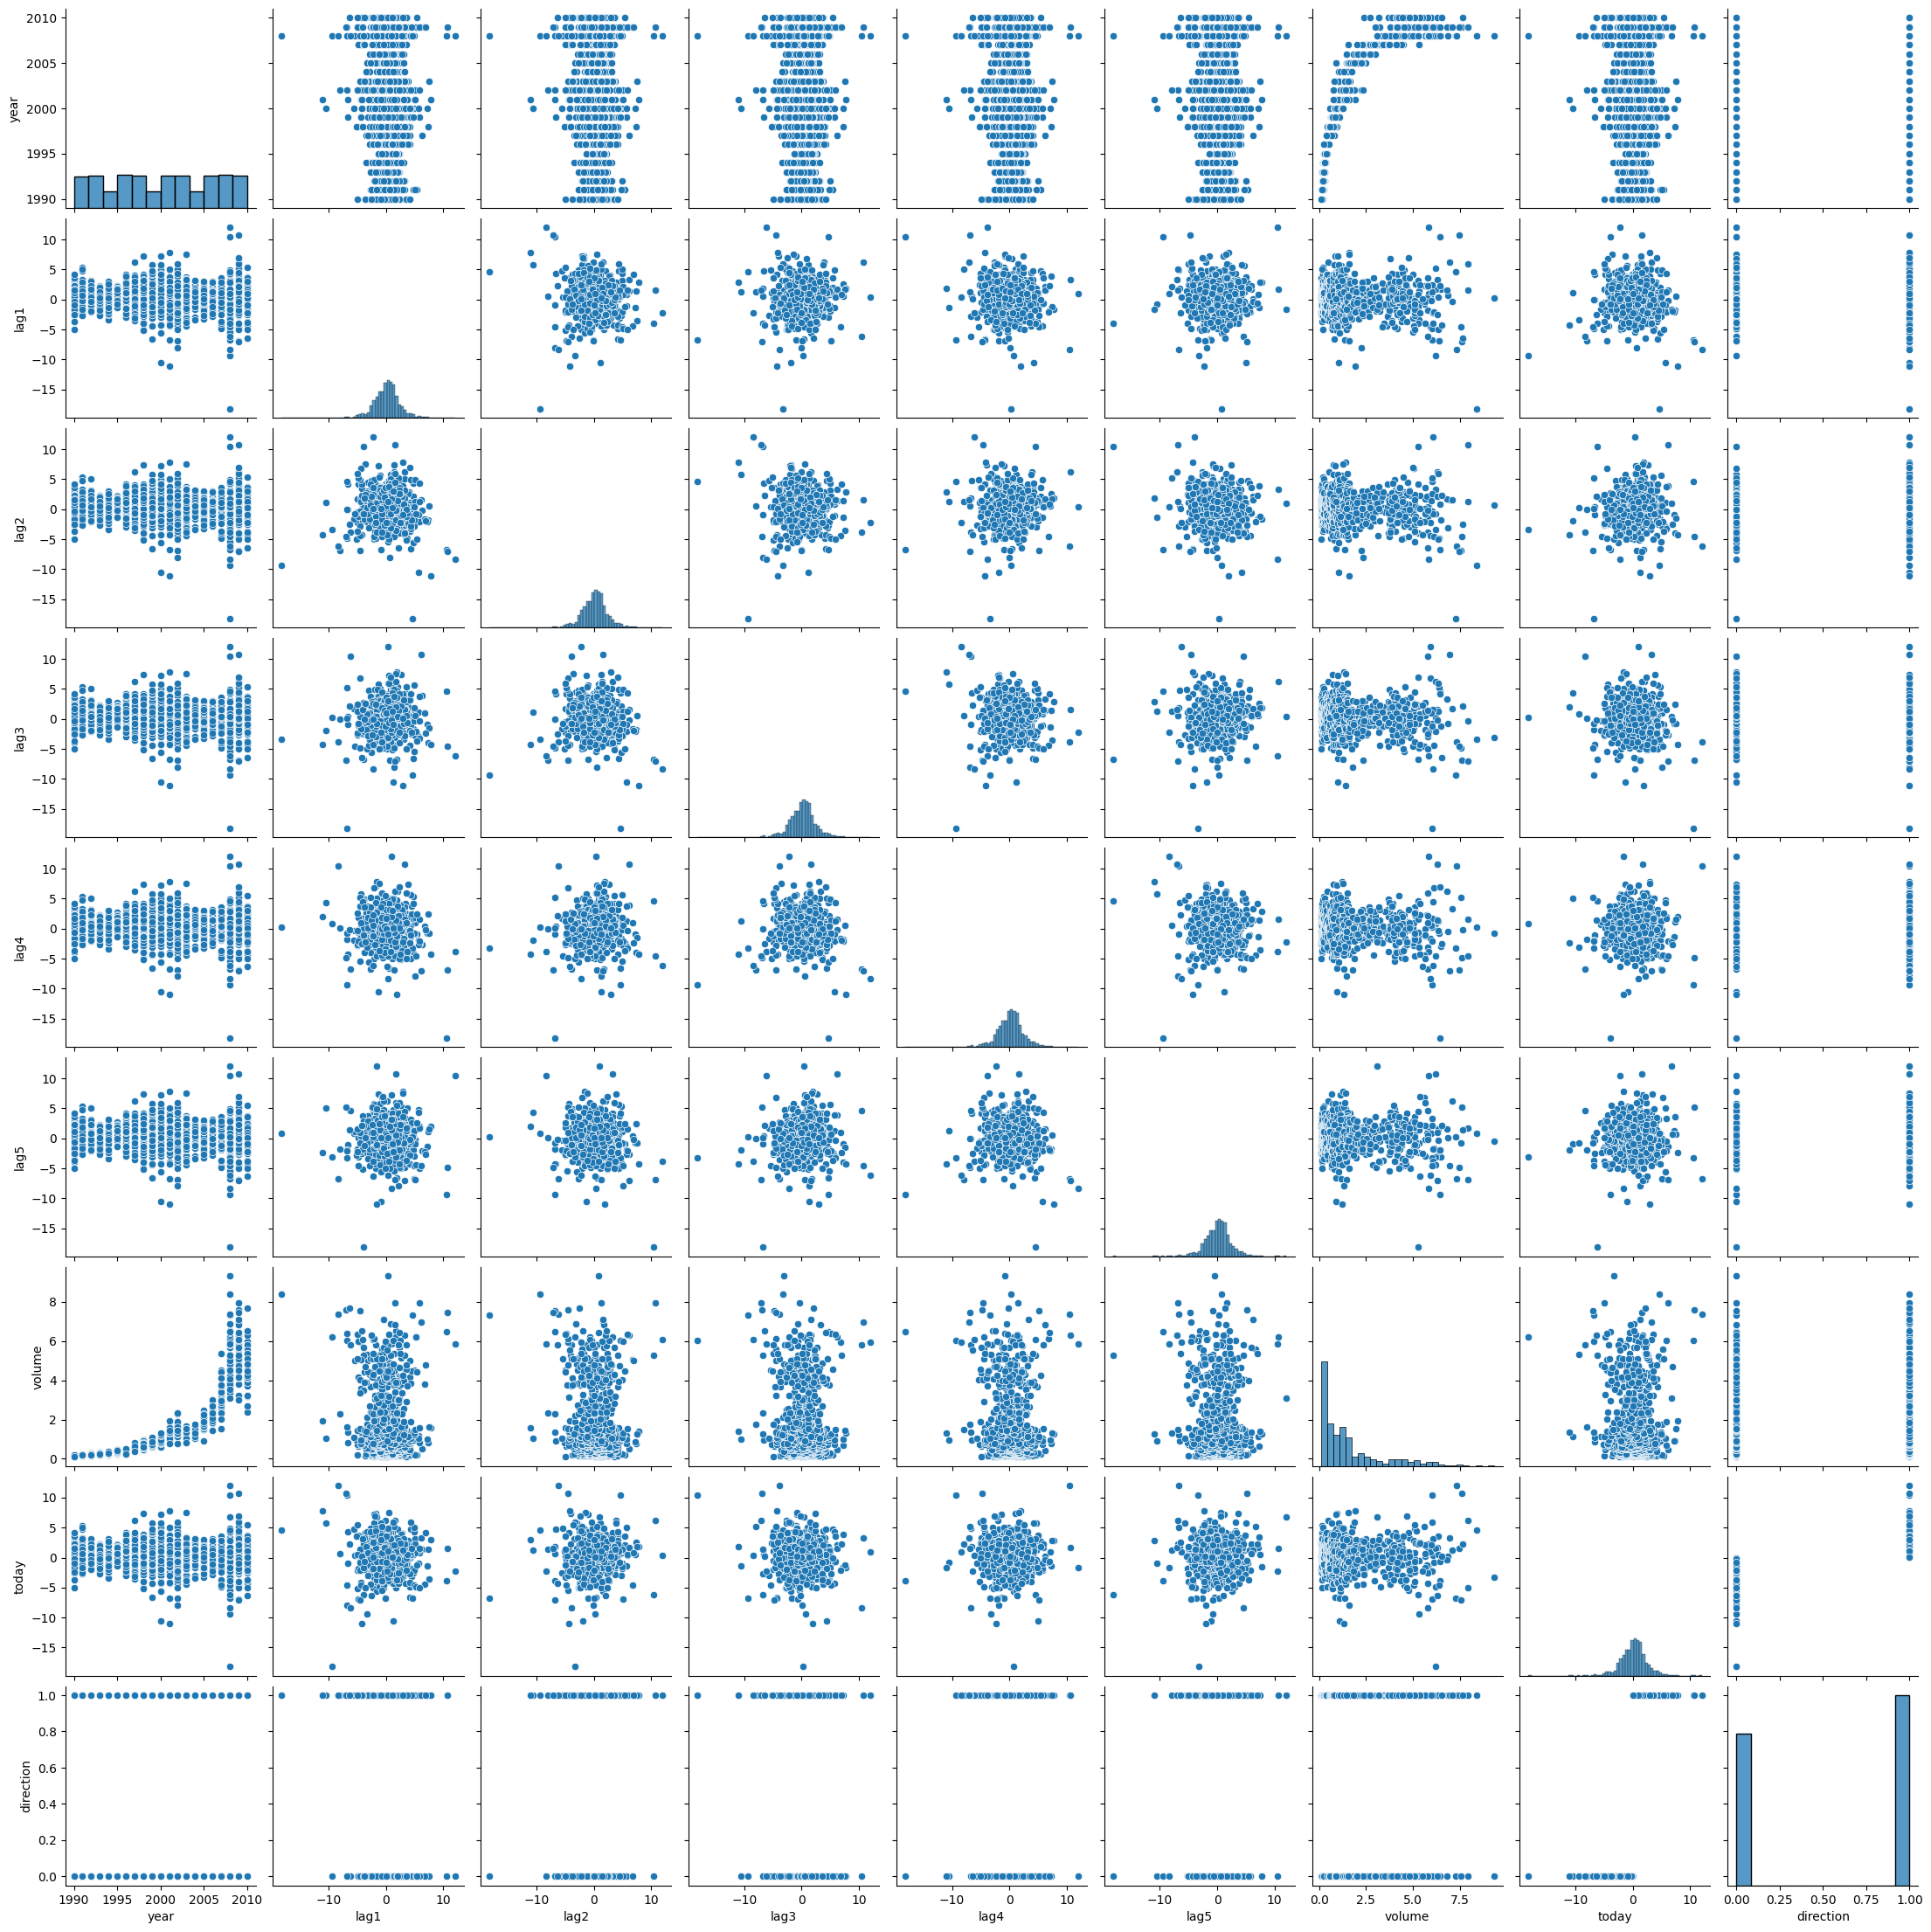

In [247]:
# Adapt the dataset to include 'direction' on the plot
weekly_modified = weekly.copy()
weekly_modified['direction'] = weekly['direction'].apply(lambda x: 1 if x=='Up' else 0)

# Plot
#pd.plotting.scatter_matrix(weekly_modified, figsize=(14,12));
sns.pairplot(weekly_modified);

In [248]:
# Get correlation values
weekly_modified.corr(numeric_only=True)

,year,lag1,lag2,lag3,lag4,lag5,volume,today,direction
year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460,-0.022200
lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032,-0.050004
lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167,0.072696
lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244,-0.022913
lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826,-0.020549
lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013,-0.018168
volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078,-0.017995
today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000,0.720025
direction,-0.022200,-0.050004,0.072696,-0.022913,-0.020549,-0.018168,-0.017995,0.720025,1.000000


The correlation metrics reinforces what we see on the scaterplot, 'year' vs 'volume' has the only significant correlation value.

#### 13b)

In the logistic regression results below, both the 'intercept' and 'lag2' are statistically significant.

In [249]:
# Create dataset
X = weekly[['lag1', 'lag2', 'lag3', 'lag4', 'lag5']].copy()
X.insert(0, 'intercept', np.ones(len(X)))
y = weekly['direction'].apply(lambda x: 1 if x=='Up' else 0)

In [250]:
model = sm.GLM(y, X, sm.families.Binomial()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1083
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.37
Date:                Sun, 27 Oct 2024   Deviance:                       1486.7
Time:                        15:59:09   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.008655
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2303      0.062      3.712      0.000       0.109       0.352
lag1          -0.0401      0.026     -1.522      0.128      -0.092       0.012
lag2           0.0602      0.027      2.249      0.025       0.008       0.113
lag3          -0.0151      0.027     -0.566      0.571      -0.067       0.037
lag4          -0.0268      0.026     -1.013      0.311      -0.079       0.025
lag5          -0.0135      0.026     -0.512      0.609      -0.065       0.038
==============================================================================
"""

#### 13c)

The confusion matrix shows that the model heavily favors 'Up' with 999 predictions and only 90 'Down' predictions. This means approximately 91.74% of all predictions are classified as 'Up', whereas the dataset has 'Up' in 58.65% of its observations.

Relying solely on the overall accuracy of 56.29% could be misleading, as it doesn't account for the model's bias towards predicting 'Up'.

In [251]:
# Predict with the model
pred = model.predict(X)
pred = pred.apply(lambda x: 1 if x > 0.5 else 0)

In [252]:
# Create the confusion matrix
cm = metrics.confusion_matrix(y, pred)
cm

array([[ 49, 435],
       [ 41, 564]])

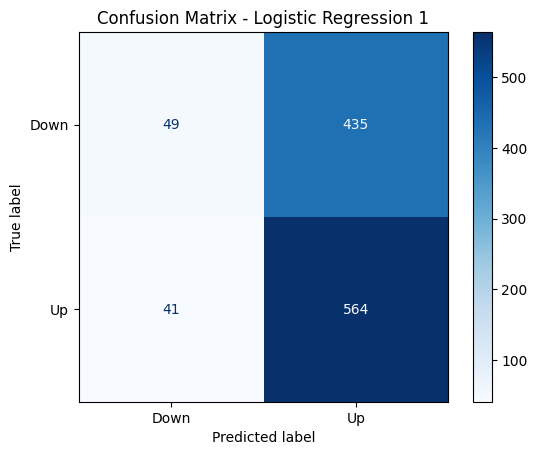

In [253]:
# Plot the confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm , display_labels=['Down','Up'])
cm_display.plot(cmap="Blues")
plt.title('Confusion Matrix - Logistic Regression 1');

In [254]:
# Overall accuracy
acc = (cm[0,0] + cm[1,1]) / cm.sum()
acc = acc * 100
print(f"Model's accuracy: {acc:.2f}%")

Model's accuracy: 56.29%


In [255]:
# Up predictions
up = sum(pred) / len(pred)
up = up * 100
print(f"The model predicts 'Up' {up:.2f}% of the time")

The model predicts 'Up' 91.74% of the time


In [256]:
# Up ratio in dataset
up_ratio = sum(y) / len(y)
up_ratio = up_ratio * 100
print(f"Up is present {up_ratio:.2f}% of the test dataset")

Up is present 55.56% of the test dataset


#### 13d) Logistic Regression

Surprisingly, the model performs better when the datset is plit, leaving unseen data (test dataset) for prediction.

The model achieves an accuracy of 62.50% on the test dataset, an improvement over the previous model. Although the bias toward 'Up' predictions remains high at 86.54%, it represents a reduction compared to earlier results.

The proportion of 'Up' occurrences in the test dataset remains consistent with the overall dataset, at 58.65%.

In [257]:
# Restrict the data for 1990-2008
X2 = weekly[weekly['year'] <= 2008]['lag2'].copy()
X2 = pd.DataFrame({'intercept': np.ones(len(X2)), 'lag2': X2})
y2 = y.loc[X2.index]

In [258]:
# Create the model
model2 = sm.GLM(y2, X2, sm.families.Binomial()).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              direction   No. Observations:                  985
Model:                            GLM   Df Residuals:                      983
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -675.27
Date:                Sun, 27 Oct 2024   Deviance:                       1350.5
Time:                        15:59:09   Pearson chi2:                     985.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.004221
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2033      0.064      3.162      0.002       0.077       0.329
lag2           0.0581      0.029      2.024      0.043       0.002       0.114
==============================================================================
"""

In [259]:
# Get test dataset - 2009+
X2_test = weekly.loc[~weekly.index.isin(X2.index)]['lag2']
X2_test = pd.DataFrame({'intercept': np.ones(len(X2_test)), 'lag2': X2_test})
y2_test = y.loc[X2_test.index]

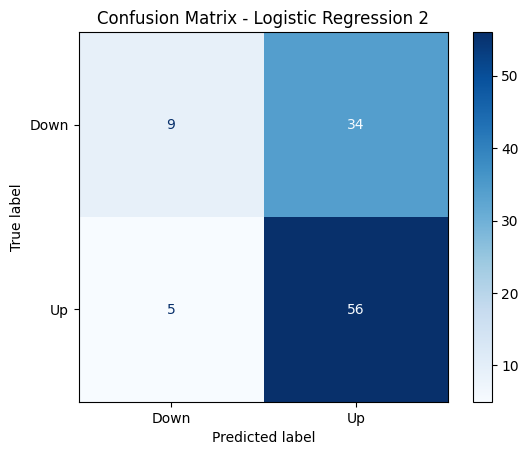

In [260]:
# Predict on test with the model
pred2_test = model2.predict(X2_test)
pred2_test = pred2_test.apply(lambda x: 1 if x > 0.5 else 0)

# Compute the confusion matrix
cm = metrics.confusion_matrix(y2_test, pred2_test)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression 2');

In [261]:
# Overall accuracy
acc = (cm[0,0] + cm[1,1]) / cm.sum()
acc = acc * 100
print(f"Model's accuracy: {acc:.2f}%")

Model's accuracy: 62.50%


In [262]:
# Up predictions
up = sum(pred2_test) / len(pred2_test)
up = up * 100
print(f"The model predicts 'Up' {up:.2f}% of the time")

The model predicts 'Up' 86.54% of the time


In [263]:
# Up in y2_test
up_test_ratio = sum(y2_test) / len(y2_test)
up_test_ratio = up_test_ratio * 100
print(f"'Up' is present {up_test_ratio:.2f}% of the test dataset")

'Up' is present 58.65% of the test dataset


#### 13e) LDA

The results are identical to those of the logistic regression:
- **Accuracy**: 62.50%
- **'Up' Predictions**: 86.54% of all predictions

In [264]:
# Create the datasets
X_train = weekly[weekly['year'] <= 2008]['lag2'].copy()
X_train = pd.DataFrame({'lag2': X_train})
X_test = weekly[weekly['year'] > 2008]['lag2'].copy()
X_test = pd.DataFrame({'lag2': X_test})
"""
obs: LDA automatically adds an intercept
"""
y_train = y.loc[X_train.index]
y_test = y.loc[X_test.index]

In [265]:
# Create and fit the model
lda = LDA(store_covariance=True)
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis(store_covariance=True)

In [266]:
# Get the average of the predictor in the two classes
lda.means_

array([[-0.03568254],
       [ 0.26036581]])

In [267]:
# Get the prior of each class
lda.priors_

array([0.44771574, 0.55228426])

In [268]:
# Predict on test dataset
lda_pred = lda.predict(X_test)

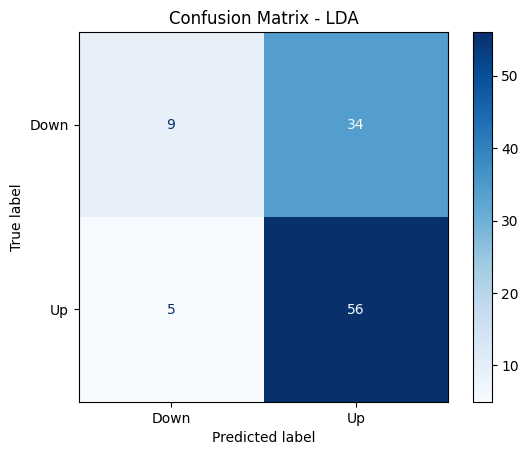

In [269]:
# Create and plot a confusion matrix
cm = metrics.confusion_matrix(y_test, lda_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
cm_display.plot(cmap="Blues")
plt.title('Confusion Matrix - LDA');

In [270]:
# Get metrics
test_up = sum(y_test)
test_size = len(y_test)
test_up_ratio = round((test_up / test_size)*100, 4)
lda_up = cm[:,1].sum()
lda_up_ratio = round((lda_up / test_size)*100, 4)
acc = round(((cm[0,0] + cm[1,1]) / test_size)*100, 4)

print(f"""
LDA's overal accuracy is {acc:.2f}%. It predicts {lda_up} 'Up' from a total of {test_size} observations. \
This provides a ratio of predicting 'Up' {lda_up_ratio:.2f}% of the time, whereas the test dataset has a \
{test_up_ratio:.2f}% 'Up' ratio.
""")


LDA's overal accuracy is 62.50%. It predicts 90 'Up' from a total of 104 observations. This provides a ratio of predicting 'Up' 86.54% of the time, whereas the test dataset has a 58.65% 'Up' ratio.



#### 13f) QDA

The results show that the model predicts the label 'Up' for every observation. This results in an accuracy of 58.65%, which reflects the frequency of 'Up' in the test dataset.

In [271]:
qda = QDA(store_covariance=True)
qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis(store_covariance=True)

In [272]:
# Get the average of the predictor in the two classes
qda.means_

array([[-0.03568254],
       [ 0.26036581]])

In [273]:
# Get the prior of each class
qda.priors_

array([0.44771574, 0.55228426])

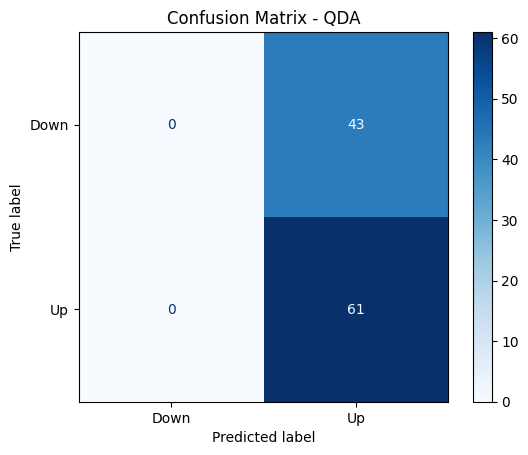

In [274]:
# Create and plot the confusion matrix
qda_pred = qda.predict(X_test)
cm = metrics.confusion_matrix(y_test, qda_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - QDA');

In [275]:
# Get metrics
test_size = len(y_test)
test_up = sum(y_test)
test_up_ratio = round((test_up / test_size)*100, 4)
qda_up = cm[:,1].sum()
qda_up_ratio = round((qda_up / test_size)*100, 4)
acc = round(((cm[0,0] + cm[1,1]) / test_size)*100, 4)

# Print information
print(f"""
QDA's overal accuracy is {acc:.2f}%. It predicts {qda_up} 'Up' from a total of {test_size} observations. \
This provides a ratio of predicting 'Up' {qda_up_ratio:.2f}% of the time, whereas the test dataset has a \
{test_up_ratio:.2f}% 'Up' ratio.
""")


QDA's overal accuracy is 58.65%. It predicts 104 'Up' from a total of 104 observations. This provides a ratio of predicting 'Up' 100.00% of the time, whereas the test dataset has a 58.65% 'Up' ratio.



#### 13g) KNN1

In [276]:
# Create the datasets
X3 = weekly[weekly['year'] <= 2008]['lag2'].copy()
X3 = pd.DataFrame({'lag2': X3})
y3 = y.loc[X3.index]
# y3 = pd.DataFrame({'direction': y3})

X3_test = weekly[~weekly.index.isin(X3.index)]['lag2']
X3_test = pd.DataFrame({'lag2': X3_test})
y3_test = y.loc[X3_test.index]
# y3_test = pd.DataFrame({'direction': y3_test})

"""
KNN measures the distance between the observation's features, so the scale of the variables matters.
Since we only have one feature ('lag2'), we can skip this preprocess.
"""

"\nKNN measures the distance between the observation's features, so the scale of the variables matters.\nSince we only have one feature ('lag2'), we can skip this preprocess.\n"

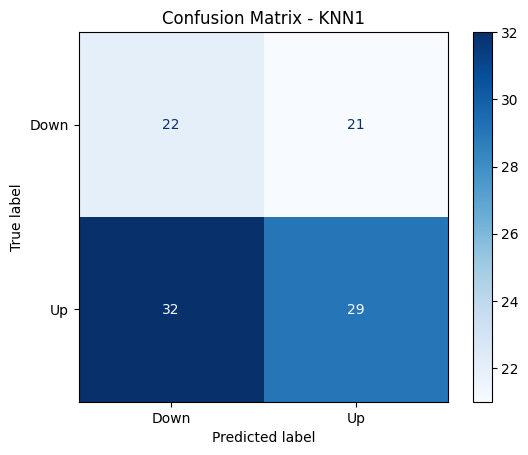

In [277]:
# Create the KNN model
knn1 = KNN(n_neighbors=1).fit(X3, y3)

# Predict on the unseen data (test)
knn1_pred = knn1.predict(X3_test)

# Create a confusion matrix
cm = metrics.confusion_matrix(y3_test, knn1_pred)

# Plot the confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - KNN1');

In [278]:
# 
knn1_pred.sum()

50

In [279]:
# Test dataset stats
test_up = y3_test.sum()
test_up_rate = round((test_up / len(y3_test))*100, 4)

# Model's 'Up' predictions
knn1_up = knn1_pred.sum()
knn1_up_rate = round((knn1_up / len(y3_test))*100, 4)

# Model's accuracy
acc = ((cm[0,0] + cm[1,1]) / len(y3_test))*100

# Print information
print(f"""
The test dataset has {test_up} 'Up' observations, which represents {test_up_rate:.2f}% of the observations. \
The model predicts {knn1_up} 'Up' observations, but only {cm[1,1]} are corret. The overall model's accuracy \
is only {acc:.2f}%.
""")


The test dataset has 61 'Up' observations, which represents 58.65% of the observations. The model predicts 50 'Up' observations, but only 29 are corret. The overall model's accuracy is only 49.04%.



**Let us test the model with standardized feature values**

In [280]:
# Standardize features/predictors
scaler = StandardScaler(with_mean=True, with_std=True, copy=True)
scaler.fit(X3)
X3_std = scaler.transform(X3)

# Standardize 
X3_test_std = scaler.transform(X3_test)

In [281]:
# Create the KNN model
knn1_std = KNN(n_neighbors=1).fit(X3_std, y3)

# Predict
knn1_pred_std = knn1_std.predict(X3_test_std)

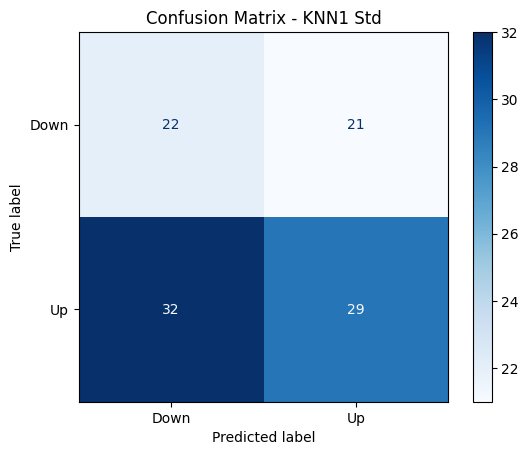

In [282]:
# Confusion matrix
cm = metrics.confusion_matrix(y3_test, knn1_pred_std)

# Plot confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - KNN1 Std');

In [283]:
# Check predictions between models
pred_size = len(knn1_pred_std)
pred_similarities = sum(knn1_pred_std == knn1_pred)

# Print info
print(f"""
Our test dataset and its prediction have {pred_size} observations. The prediction similarities between KNN \
models with standardized and non-standardized have a total of {pred_similarities}. This means that the \
assumption that they are all equal is {pred_similarities == pred_size}.
""")


Our test dataset and its prediction have 104 observations. The prediction similarities between KNN models with standardized and non-standardized have a total of 104. This means that the assumption that they are all equal is True.



#### 13h) Naive Bayes

The Naive Bayes model, similarly to the QDA, only predicts 'Up'.

In [284]:
# Create and fit Naive Bayes model
nb = GaussianNB()
nb.fit(X3, y3)

GaussianNB()

In [285]:
#dir(nb)

In [286]:
# Print some info
print(f"""
Classes:      \t{nb.classes_}
Prior:        \t{nb.class_prior_}
Params Shape: \t{nb.theta_.shape} (classes, params)

Params Values:
{nb.theta_}
""")


Classes:      	[0 1]
Prior:        	[0.44771574 0.55228426]
Params Shape: 	(2, 1) (classes, params)

Params Values:
[[-0.03568254]
 [ 0.26036581]]



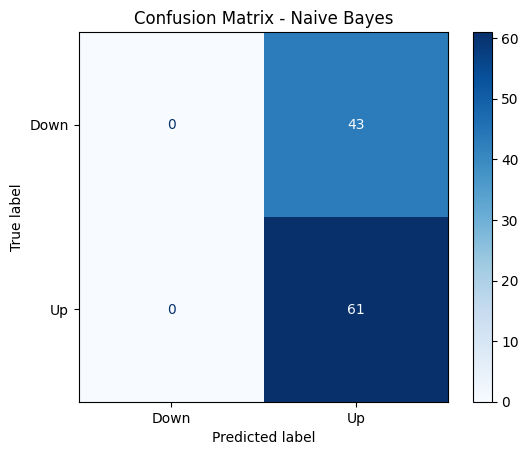

In [287]:
# Predict & plot confusion matrix
nb_pred = nb.predict(X3_test)
cm = metrics.confusion_matrix(y3_test, nb_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - Naive Bayes');

In [288]:
# Overal accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
acc

58.65

#### 13i)

#### Best Results

- Logistic Regression: 62.50%
- LDA: 62.50%
- QDA: 58.65%
- Naive Bayes: 58.65%
- KNN 1: 49.04%%


The models with the best performance are LDA and Logistic Regression, which provided identical results. Both achieved on overall accuracy of 62.50% and predicted 'Up' 90 times out of 104 total observations. This indicates a bias toward predicting 'Up', as it was labeled 86.54% of the time, despite the test dataset containing only 58.65% 'Up' observations.

#### 13j)

#### Best Results

- KNN 6: 56.73%
- Logistic Regression: 54.81%
- LDA: 54.81%
- Naive Bayes: 48.08%
- QDA: 46.15%

After including all 'lag' features in the training and testing datasets, the accuracy of all models, except the KNN model with 6 neighors, decreased. The KNN model, a non-parametric approach, was the only to benefit from the added complexity of the additional features. KNN, with its flexible decision boundaries, was able to capitalize on the new features.

In [289]:
# Create a dataset with all lags
X_train = weekly[weekly['year'] <= 2008].iloc[:, 1:6].copy()
X_test = weekly[weekly['year'] > 2008].iloc[:, 1:6].copy()
y_train = weekly[weekly['year'] <= 2008]['direction'].copy()
y_test = weekly[weekly['year'] > 2008]['direction'].copy()

# Adapt 'y' into binary integer dummy
y_train = y_train.apply(lambda x: 1 if x=='Up' else 0)
y_test = y_test.apply(lambda x: 1 if x=='Up' else 0)

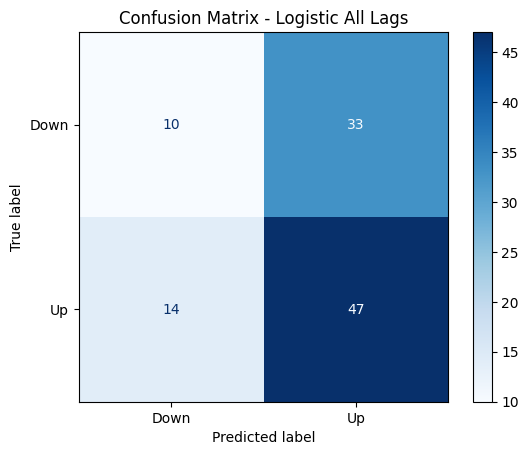

In [290]:
############
# LOGISTIC #
############

# Add intercept
X_train.insert(0, 'intercept', np.ones(len(X_train)))
X_test.insert(0, 'intercept', np.ones(len(X_test)))

# Create and fit the model
logistic1 = sm.GLM(y_train, X_train, sm.families.Binomial()).fit()

# Predict
pred = logistic1.predict(X_test)
pred = pred.apply(lambda x: 1 if x>0.5 else 0)

# Create and plot a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic All Lags');

In [291]:
# Get test accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)

# Get test up ratio
up_ratio = round((y_test.sum() / len(y_test))*100, 2)

# Print basic info
print(f"""
Logistic acc:   \t{acc}%
Test 'Up' ratio:\t{up_ratio}%
""")


Logistic acc:   	54.81%
Test 'Up' ratio:	58.65%



#### LDA

The LDA model has the same response as the Logistic Regression model. There is a considerable accuracy drop when comparing the previous model using only 'lag2' when compared to the current model using all 'lags'. The accuracy goes from 62.50% to 54.81% on the test dataset.

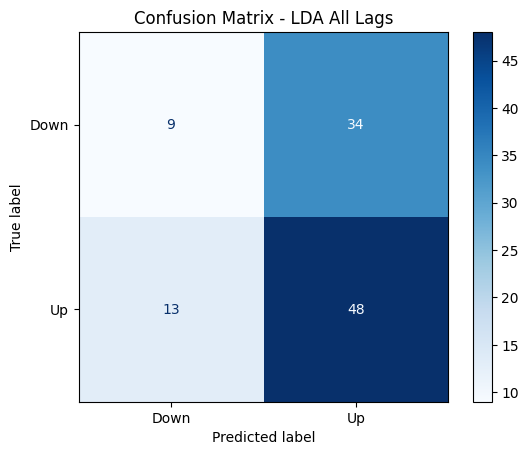

In [292]:
#######
# LDA #
#######
# Create the datasets
X_train.drop(columns='intercept', inplace=True)
X_test.drop(columns='intercept', inplace=True)
"""
obs: LDA automatically adds an intercept
"""

# Create and fit the model
lda1 = LDA(store_covariance=True)
lda1.fit(X_train, y_train)

# Predict
pred = lda1.predict(X_test)

# Create and plot a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - LDA All Lags');

In [293]:
# Get the test accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)

# Print basic info
print(f"""
LDA acc:        \t{acc}%
Test 'Up' ratio:\t{up_ratio}%
""")


LDA acc:        	54.81%
Test 'Up' ratio:	58.65%



In [294]:
# Get the average of each predictor within each class
lda1.means_

array([[ 0.28944444, -0.03568254,  0.17080045,  0.15925624,  0.21409297],
       [-0.00921324,  0.26036581,  0.08404044,  0.09220956,  0.04548897]])

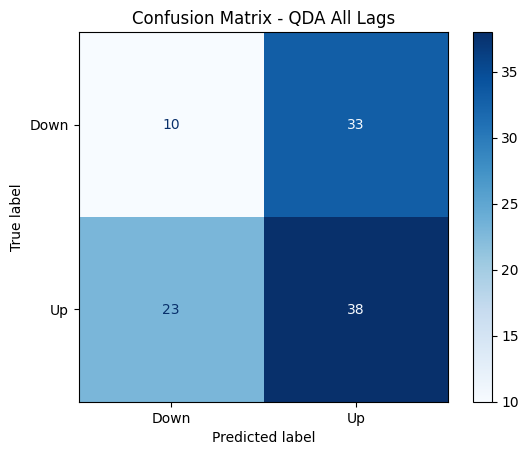

In [295]:
#######
# QDA #
#######
# Create and fit the model
qda1 = QDA(store_covariance=True)
qda1.fit(X_train, y_train)

# Predict
pred = qda1.predict(X_test)

# Create and plot a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - QDA All Lags');

In [296]:
# Get the test accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)

# Print basic info
print(f"""
QDA acc:        \t{acc}%
Test 'Up' ratio:\t{up_ratio}%
""")


QDA acc:        	46.15%
Test 'Up' ratio:	58.65%



In [297]:
# Get the average of each predictor within each class
qda1.means_

array([[ 0.28944444, -0.03568254,  0.17080045,  0.15925624,  0.21409297],
       [-0.00921324,  0.26036581,  0.08404044,  0.09220956,  0.04548897]])

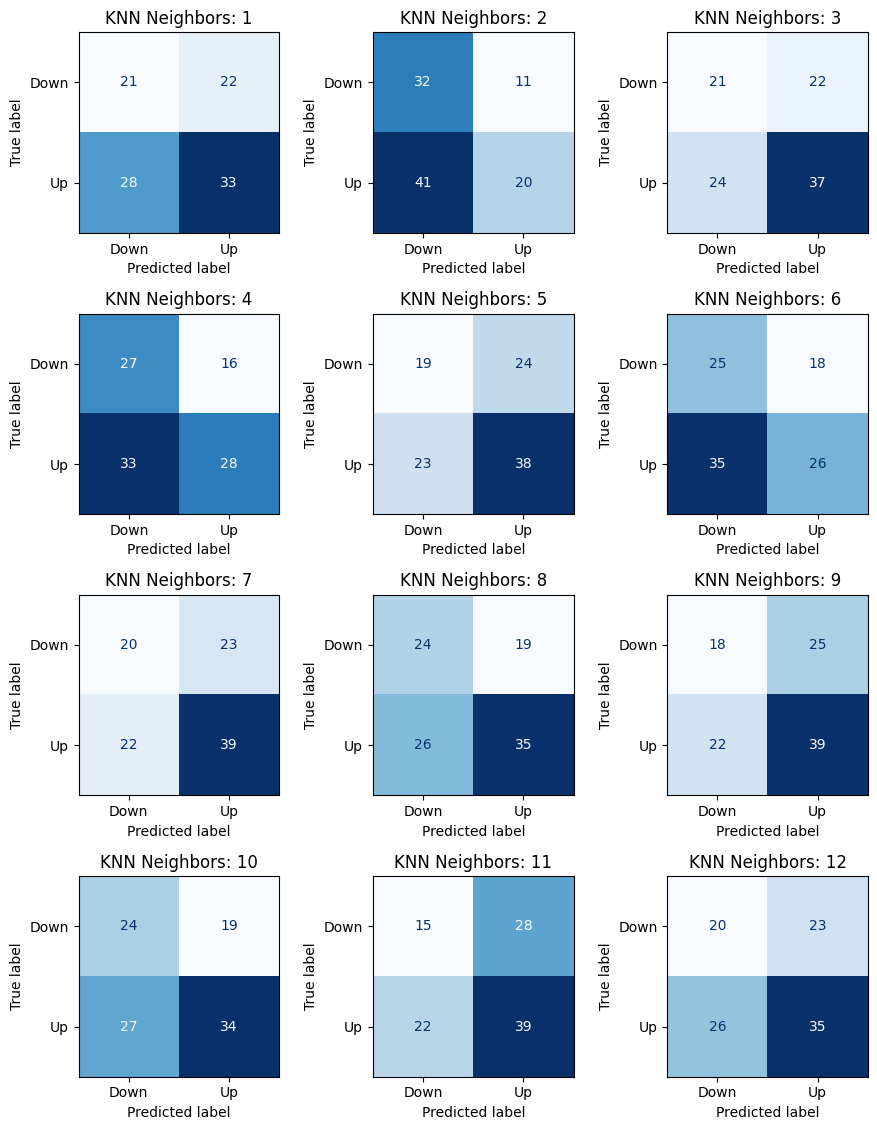

In [298]:
#######
# KNN #
#######
# Initialize variables
knn_acc = []
n_neighbors_range = range(1, 13)

# Create a figure and subplots grid
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(9, 12))  # Adjust size as needed
#fig.suptitle('Confusion Matrices for KNN with Varying Neighbors', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through the range of neighbors
for i, ax in enumerate(axes[:len(n_neighbors_range)]):
    # Create and fit the model
    knn = KNN(n_neighbors=n_neighbors_range[i])
    knn.fit(X_train, y_train)
    
    # Predict on test dataset & create a confusion matrix
    pred = knn.predict(X_test)
    cm = metrics.confusion_matrix(y_test, pred)
    
    # Plot the confusion matrix in the respective subplot
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
    cm_display.plot(cmap='Blues', ax=ax, colorbar=False)  # Disable individual colorbars for clarity
    
    ax.set_title(f'KNN Neighbors: {n_neighbors_range[i]}')
    
    # Get the test accuracy and append to list
    acc = round(((cm[0, 0] + cm[1, 1]) / len(y_test)) * 100, 2)
    knn_acc.append(acc)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for suptitle
plt.show()

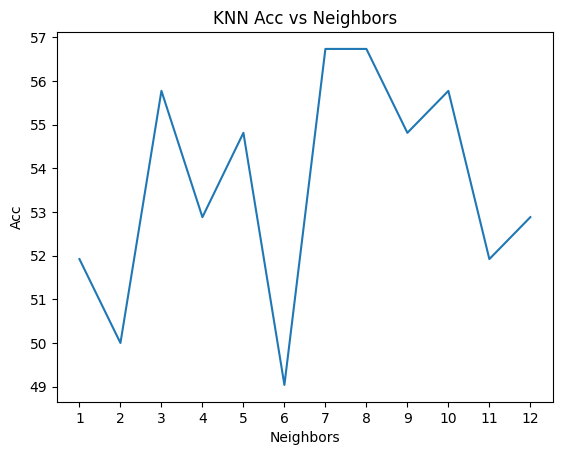

In [299]:
# Plot KNN accuracies
plt.plot(range(1,13), knn_acc)
plt.title('KNN Acc vs Neighbors')
plt.ylabel('Acc')
plt.xlabel('Neighbors')
plt.xticks(range(1,13))

# # Add labels to each point on the plot
# for i, acc in enumerate(knn_acc, start=1):
#     plt.text(i, acc, f'{acc:.2f}', ha='center', va='bottom')

# Show the plot
plt.show();

In [300]:
# Highest accuracy
max(knn_acc)

56.73

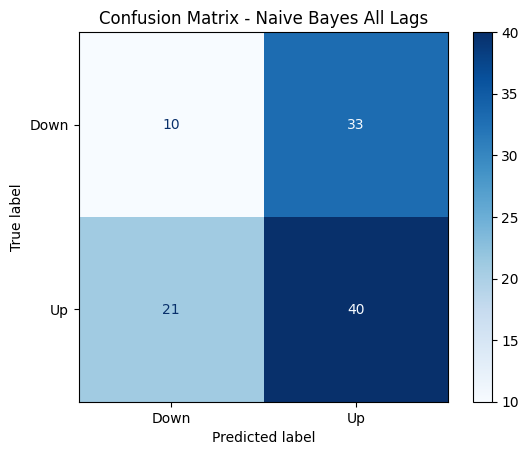

In [301]:
###############
# Naive Bayes #
###############
# Create and fit the model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict
pred = nb.predict(X_test)
pred = np.where(pred > 0.5, 1, 0)

# Create and plot a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - Naive Bayes All Lags');

In [302]:
# Get the test accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)

# Print basic info
print(f"""
Naive Bayes acc:\t{acc}%
Test 'Up' ratio:\t{up_ratio}%
""")


Naive Bayes acc:	48.08%
Test 'Up' ratio:	58.65%



In [303]:
# Create polynomials
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)
features_name = poly.get_feature_names_out(input_features=X_train.columns)

# Create a dataframe
X_train2 = pd.DataFrame(X_train_poly, columns=features_name)
X_test2 = pd.DataFrame(X_test_poly, columns=features_name)

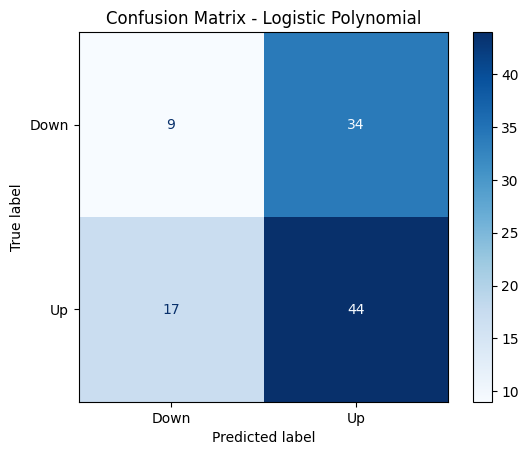

In [304]:
############
# LOGISTIC #
############

# Add intercept
X_train2.insert(0, 'intercept', np.ones(len(X_train)))
X_test2.insert(0, 'intercept', np.ones(len(X_test)))

# Create and fit the model
logistic1 = sm.GLM(y_train, X_train2, sm.families.Binomial()).fit()

# Predict
pred = logistic1.predict(X_test2)
pred = pred.apply(lambda x: 1 if x>0.5 else 0)

# Create and plot a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Polynomial');

In [305]:
# Get test accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)

# Get test up ratio
up_ratio = round((y_test.sum() / len(y_test))*100, 2)

# Print basic info
print(f"""
Logistic acc:   \t{acc}%
Test 'Up' ratio:\t{up_ratio}%
""")


Logistic acc:   	50.96%
Test 'Up' ratio:	58.65%



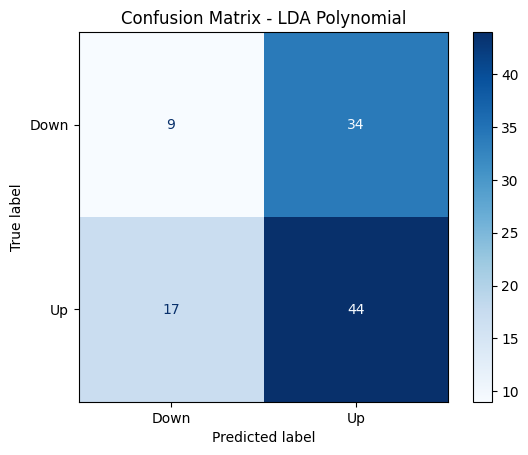

In [306]:
#######
# LDA #
#######
# Create the datasets
X_train2.drop(columns='intercept', inplace=True)
X_test2.drop(columns='intercept', inplace=True)
"""
obs: LDA automatically adds an intercept
"""

# Create and fit the model
lda2 = LDA(store_covariance=True)
lda2.fit(X_train2, y_train)

# Predict
pred = lda2.predict(X_test2)

# Create and plot a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - LDA Polynomial');

In [307]:
# Get test accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)

# Get test up ratio
up_ratio = round((y_test.sum() / len(y_test))*100, 2)

# Print basic info
print(f"""
LDA acc:        \t{acc}%
Test 'Up' ratio:\t{up_ratio}%
""")


LDA acc:        	50.96%
Test 'Up' ratio:	58.65%



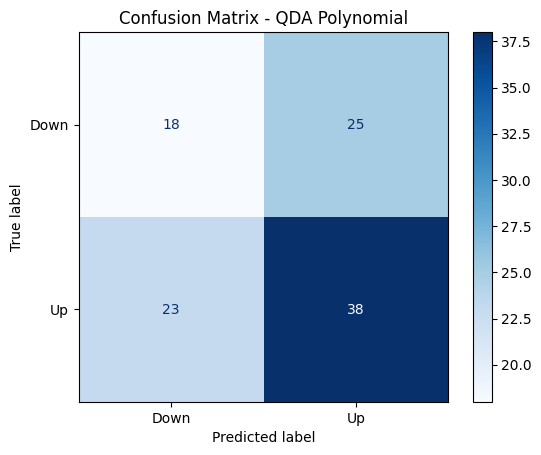

In [308]:
#######
# QDA #
#######
# Create and fit the model
qda2 = QDA(store_covariance=True)
qda2.fit(X_train2, y_train)

# Predict
pred = qda2.predict(X_test2)

# Create and plot a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix - QDA Polynomial');

In [309]:
# Get test accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)

# Get test up ratio
up_ratio = round((y_test.sum() / len(y_test))*100, 2)

# Print basic info
print(f"""
QDA acc:        \t{acc}%
Test 'Up' ratio:\t{up_ratio}%
""")


QDA acc:        	53.85%
Test 'Up' ratio:	58.65%



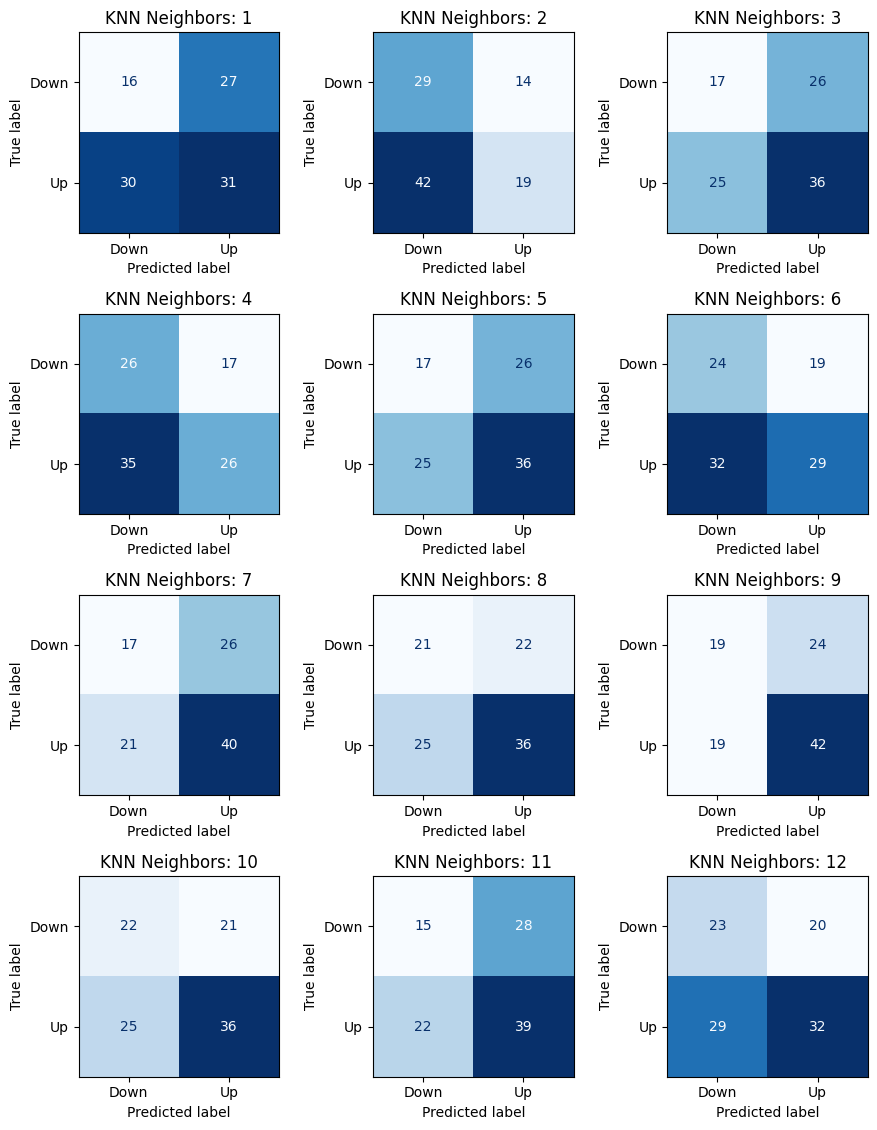

In [310]:
#######
# KNN #
#######
# Initialize variables
knn_acc = []
n_neighbors_range = range(1, 13)

# Create a figure and subplots grid
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(9, 12))  # Adjust size as needed
#fig.suptitle('Confusion Matrices for KNN with Varying Neighbors', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through the range of neighbors
for i, ax in enumerate(axes[:len(n_neighbors_range)]):
    # Create and fit the model
    knn = KNN(n_neighbors=n_neighbors_range[i])
    knn.fit(X_train2, y_train)
    
    # Predict on test dataset & create a confusion matrix
    pred = knn.predict(X_test2)
    cm = metrics.confusion_matrix(y_test, pred)
    
    # Plot the confusion matrix in the respective subplot
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
    cm_display.plot(cmap='Blues', ax=ax, colorbar=False)  # Disable individual colorbars for clarity
    
    ax.set_title(f'KNN Neighbors: {n_neighbors_range[i]}')
    
    # Get the test accuracy and append to list
    acc = round(((cm[0, 0] + cm[1, 1]) / len(y_test)) * 100, 2)
    knn_acc.append(acc)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for suptitle
plt.show()

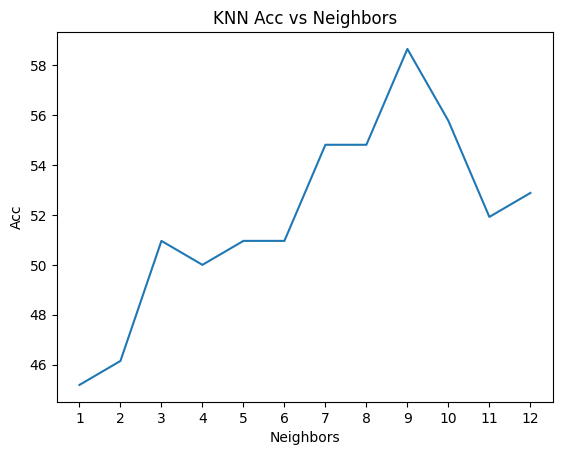

In [311]:
# Plot KNN accuracies
plt.plot(range(1,13), knn_acc)
plt.title('KNN Acc vs Neighbors')
plt.ylabel('Acc')
plt.xlabel('Neighbors')
plt.xticks(range(1,13))

# Show the plot
plt.show();

In [312]:
# Highest accuracy
max(knn_acc)

58.65

---

### Question 14

#### 14a)

In [313]:
# Load data
auto = pd.read_csv('data/Auto.csv')

# Adapt column names
auto.columns = [x.lower() for x in auto.columns]

In [314]:
# Get basic info from the dataset
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB


In [315]:
# Find and remove non-numerical values from 'horsepower'
idx = auto['horsepower'].apply(lambda x: x.isnumeric())
auto = auto.loc[idx]

# Adapt 'horsepower' column
auto['horsepower'] = auto['horsepower'].astype(float)

# Get new basic info
auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.6+ KB


In [316]:
# Get the median value for mpg
mpg_median = auto['mpg'].median()

# Create a dummy variable
auto['mpg01'] = auto['mpg'].apply(lambda x: 1 if x > mpg_median else 0)

#### 14b)

When exploring the data visually, it's possible to identify several patterns between 'mpg' and other variables. For example, we see an increase in 'mpg' when we decrease the value of 'cylinders', 'displacement', 'horsepower' and 'weight'. This suggests a negative relation between these features and 'mpg', which is confirmed the the correlation values below the graph.

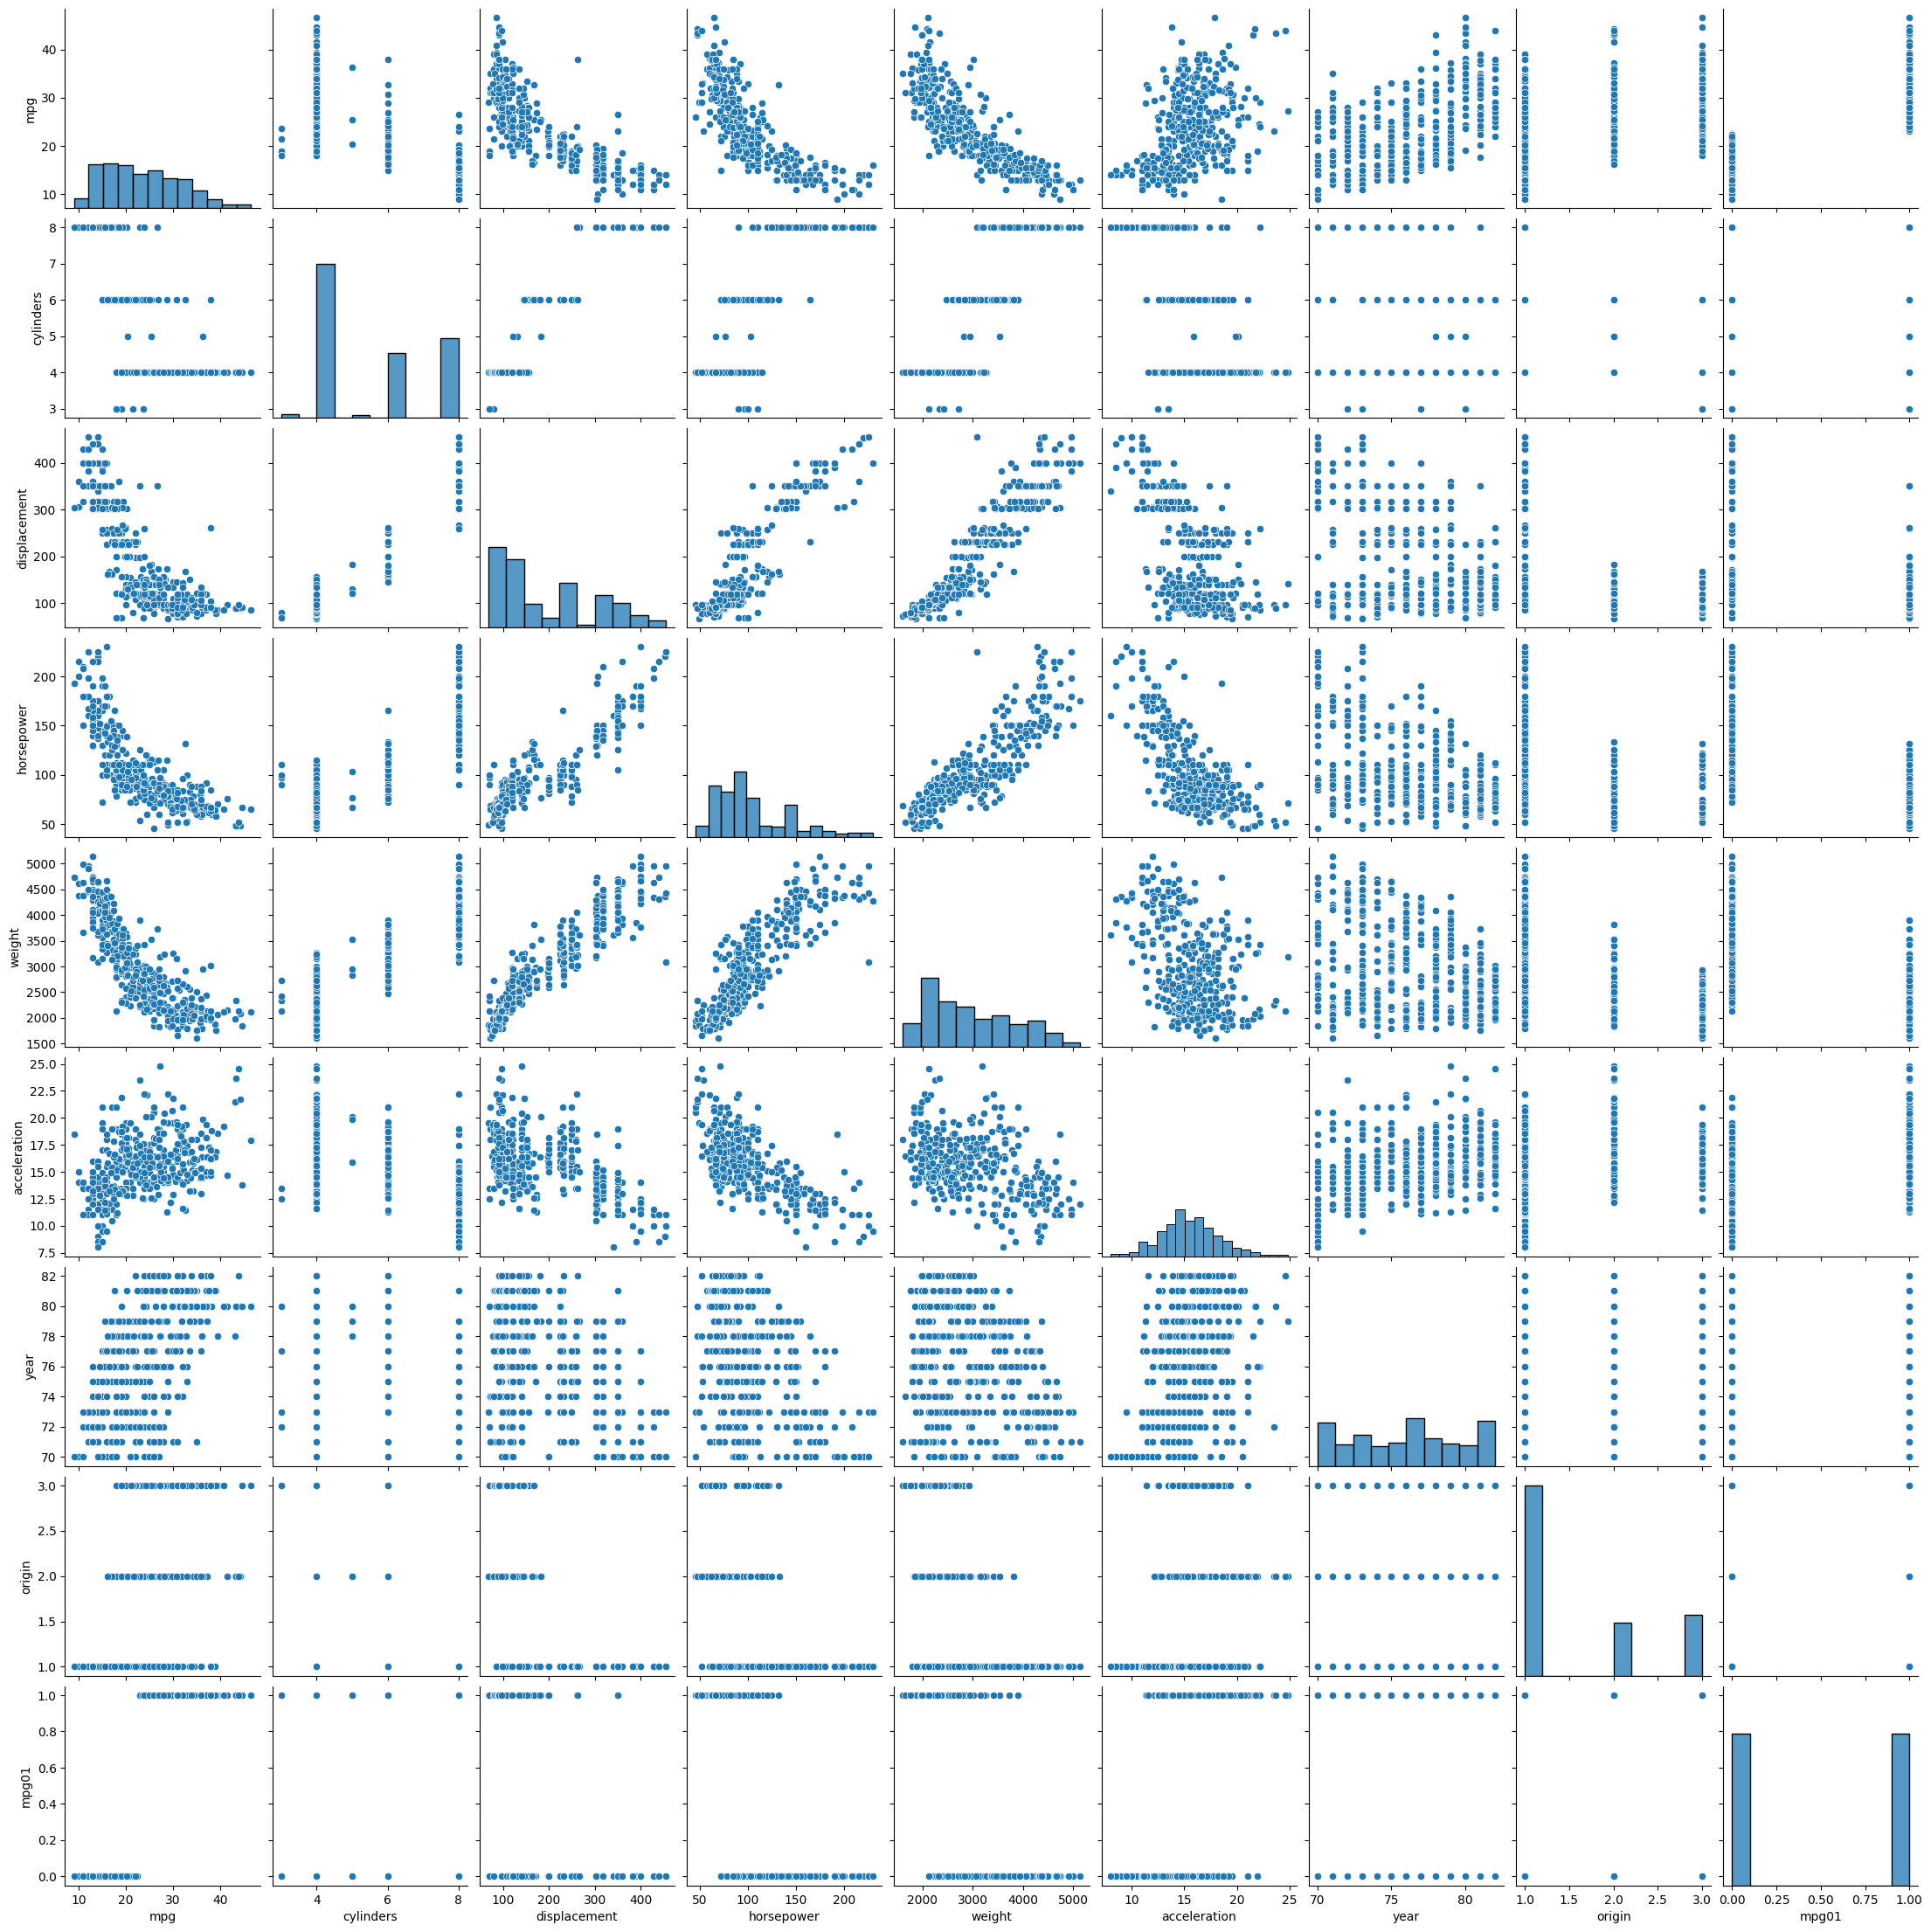

In [317]:
# Plot
#pd.plotting.scatter_matrix(auto, figsize=(14,12));
sns.pairplot(auto);

In [318]:
auto.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209,0.836939
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932,-0.759194
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535,-0.753477
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.667053
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005,-0.757757
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746,0.346822
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528,0.429904
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000,0.513698
mpg01,0.836939,-0.759194,-0.753477,-0.667053,-0.757757,0.346822,0.429904,0.513698,1.000000


#### 14c)

In [319]:
# Split the data into train and test
X = auto.iloc[:, 1:5].copy() # most associated with mpg
y = auto['mpg01']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

#### 14d)

The LDA model demonstrates strong performance in predicting whether a car's mpg will be above or below the median. On the test dataset, the model achieves an error rate of 7.14%, indicating an accuracy of 92.86% in its predictions.

In [320]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 259 to 38
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     294 non-null    int64  
 1   displacement  294 non-null    float64
 2   horsepower    294 non-null    float64
 3   weight        294 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 11.5 KB


In [321]:
# Create and fit LDA model
lda = LDA(store_covariance=True)
lda.fit(X_train, y_train)

# Predict
pred = lda.predict(X_test)

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)

# Get the accuracy and error rate
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
error = round(100 - acc, 2)
print(f"""
LDA acc:   \t{acc}%
LDA error: \t{error}%
""")


LDA acc:   	92.86%
LDA error: 	7.14%



#### 14e)

The QDA model provides improvement when compared to LDA results. The model's accuracy is 93.88% and the error rate is 6.12%.

In [322]:
# Create and fit QDA model
qda = QDA(store_covariance=True)
qda.fit(X_train, y_train)

# Predict
pred = qda.predict(X_test)

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)

# Get the accuracy and error rate
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
error = round(100 - acc, 2)
print(f"""
QDA acc:  \t{acc}%
QDA error:\t{error}%
""")


QDA acc:  	93.88%
QDA error:	6.12%



#### 14.f)

We evaluated two logistic regression models:

1. Using default parameters.
2. Minimal regularization (setting very high parameter value).

The model with the default settings achieved a higher accuracy (93.88% vs 91.84%), demonstrating that L2 regularization contributes to improving the model's performance. This is usually attributed to preventing overfitting and better generalization.

In [323]:
# Add intercept for the Logistic Regression model
X_train.insert(0, 'intercept', np.ones(len(X_train)))
X_test.insert(0, 'intercept', np.ones(len(X_test)))

# Create and fit the model
logistic = sm.GLM(y_train, X_train, sm.families.Binomial()).fit()

# Predict
pred = logistic.predict(X_test)
pred = pred.apply(lambda x: 1 if x>0.5 else 0)

# Create and plot a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)

# Get the accuracy and error rate
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
error = round(100 - acc, 2)
print(f"""
Logistic acc:  \t{acc}%
Logistic error:\t{error}%
""")


Logistic acc:  	91.84%
Logistic error:	8.16%



In [324]:
logistic.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  mpg01   No. Observations:                  294
Model:                            GLM   Df Residuals:                      289
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -87.577
Date:                Sun, 27 Oct 2024   Deviance:                       175.15
Time:                        15:59:19   Pearson chi2:                     415.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5459
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept        9.4939      1.716      5.531      0.000       6.130      12.858
cylinders        0.0715      0.370      0.193      0.847      -0.653       0.796
displacement    -0.0171      0.009     -1.879      0.060      -0.035       0.001
horsepower      -0.0388      0.015     -2.589      0.010      -0.068      -0.009
weight          -0.0011      0.001     -1.496      0.135      -0.003       0.000
================================================================================
"""

In [325]:
"""
sklearn's logistic regression focuses more on classificaiton rather than inference.
"""
# Logistic regression with sklearn package
logit1 = LogisticRegression()
logit1 = logit1.fit(X_train, y_train)

# Try different arguments
logit2 = LogisticRegression(C=1e10, solver='liblinear')
logit2 = logit2.fit(X_train, y_train)

# Predictions
pred1 = logit1.predict(X_test)
pred1 = np.where(pred1 > 0.5, 1, 0)
pred2 = logit2.predict(X_test)
pred2 = np.where(pred2 > 0.5, 1, 0)

# Create confusion matricies
cm1 = metrics.confusion_matrix(y_test, pred1)
cm2 = metrics.confusion_matrix(y_test, pred2)

# Get accuracy and error
acc1 = round(((cm1[0,0] + cm1[1,1]) / len(y_test))*100, 2)
error1 = round(100 - acc1, 2)
acc2 = round(((cm2[0,0] + cm2[1,1]) / len(y_test))*100, 2)
error2 = round(100 - acc2, 2)

print(f"""
Logistic1 acc:   \t{acc1}%
Logistic1 error: \t{error1}%

Logistic2 acc:   \t{acc2}%
Logistic2 error: \t{error2}%
""")



Logistic1 acc:   	93.88%
Logistic1 error: 	6.12%

Logistic2 acc:   	91.84%
Logistic2 error: 	8.16%



/home/andrey/venvs/isl/lib64/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### 14.g)

The Naive Bayes model has accuracy of 92.86% and error rate of 7.14%.

In [326]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 259 to 38
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   intercept     294 non-null    float64
 1   cylinders     294 non-null    int64  
 2   displacement  294 non-null    float64
 3   horsepower    294 non-null    float64
 4   weight        294 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 13.8 KB


In [327]:
# Drop the intercept
X_train.drop(columns='intercept', inplace=True)
X_test.drop(columns='intercept', inplace=True)

In [328]:
# Create and fit the Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict on the test dataset
pred = nb.predict(X_test)

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)

# Get accuracy and error rate
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
error = round(100 - acc, 2)
print(f"""
Naive Bayes acc:   \t{acc}%
Naive Bayes error: \t{error}%
""")


Naive Bayes acc:   	92.86%
Naive Bayes error: 	7.14%



#### 14h)

KNN achieves its peak performance at 90.82% accuracy with a 9.18% error rate, indicating a plateau in its effectiveness for this classificaiton task. KNN's limited success when compare to other models may be attributed to a combination of factors: relatively small dataset size and the likelihood that the decision boundary is not highly complex or non-linear, reducing KNN's advantages.

In [329]:
# Initialize lists that will hold models' performances
acc_list = []
error_list = []

# Create and fit a range of KNN models
for i in range(1,15):
    knn = KNN(n_neighbors=i)
    knn.fit(X_train, y_train)

    # Predict
    pred = knn.predict(X_test)

    # Get accuracy
    cm = metrics.confusion_matrix(y_test, pred)
    acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
    error = round(100 - acc, 2)

    # Store information
    acc_list.append(acc)
    error_list.append(error)

print(f"""
KNN max accuracy: \t{max(acc_list)}%
KNN min error:    \t{min(error_list)}%
KNN best n:       \t{acc_list.index(max(acc_list))} neighbors
""")


KNN max accuracy: 	90.82%
KNN min error:    	9.18%
KNN best n:       	7 neighbors



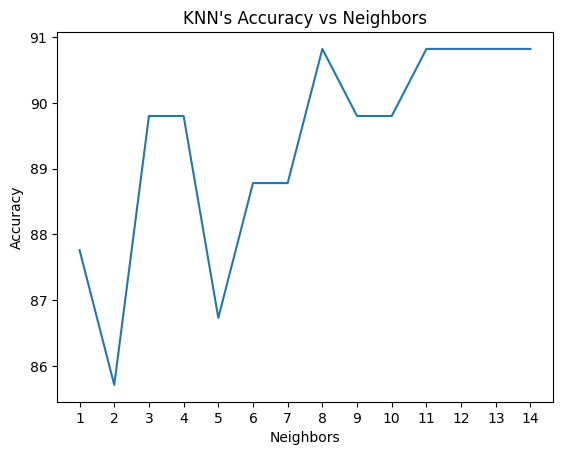

In [330]:
# Plot KNN results
plt.plot(range(1,15), acc_list)
plt.xticks(range(1,15))
plt.xlabel('Neighbors')
plt.ylabel('Accuracy')
plt.title("KNN's Accuracy vs Neighbors");

---

### Question 15

#### 15a)


In [331]:
# Create power function
def Power():
    result = 2**3
    print(f'result: {result}')

In [332]:
# Call the function
Power()

result: 8


#### 15b)

In [333]:
# Create second power function
def Power2(x, a):
    result = x**a
    print(f'result: {result}')

In [334]:
# Call the function
Power2(3, 8)

result: 6561


#### 15c)

In [335]:
# Call the function
Power2(10, 3)
Power2(8, 17)
Power2(131, 3)

result: 1000
result: 2251799813685248
result: 2248091


#### 15d)

In [336]:
# Create third power function
def Power3(x, a):
    result = x**a
    return result

#### 15e)

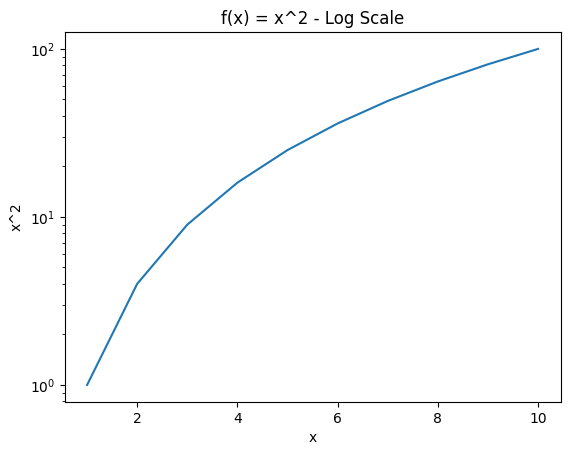

In [337]:
# Generate data
x = range(1, 11)
y = []
for value in x:
    y.append(Power3(value, 2))

# Plot
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('x^2')
plt.yscale('log')
plt.title('f(x) = x^2 - Log Scale');

#### 15f)

In [338]:
# Create PLotPower function
def PlotPower(x, a):
    # Compute 'y'
    y = []
    for value in x:
        y.append(value**a)

    # Plot
    plt.plot(x, y)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(f'f(x) = x^{a}')
    plt.show();

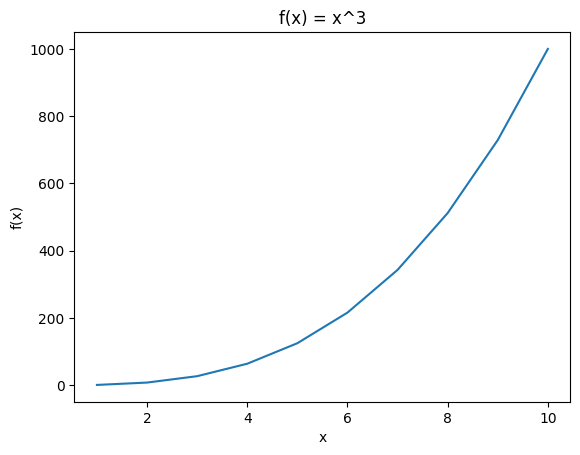

In [339]:
# Plot with the function
PlotPower(np.arange(1,11), 3)

---

#### Question 16

In [340]:
# Load the dataset
boston = pd.read_csv('data/Boston.csv')

# Check basic info
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 55.5 KB


In [341]:
# Check the initial observations
boston.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [342]:
# Drop the first column
boston = boston.iloc[:, 1:].copy()

# Calculate 'crim' median
crim_median = boston['crim'].median()

# Create response variable
boston['crime01'] = boston['crim'].apply(lambda x: 1 if x > crim_median else 0)

In [343]:
# Look at a few observations
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,crime01
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,0
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,0
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,0


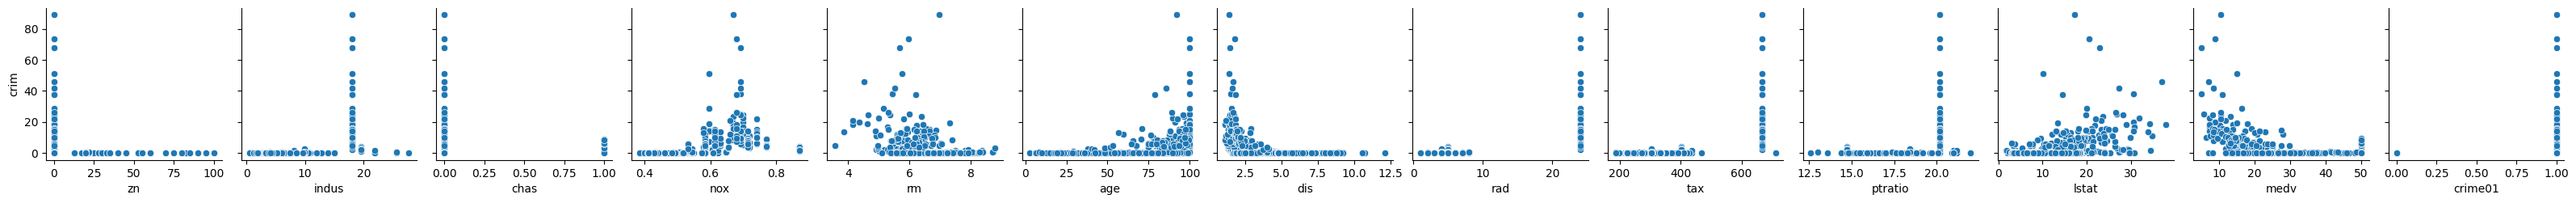

In [344]:
# Looking closely at 'crim' vs other features/variables
sns.pairplot(boston, y_vars='crim', x_vars=boston.columns.drop('crim'));

In [345]:
# Compute correlation
boston.corr()['crim']

crim       1.000000
zn        -0.200469
indus      0.406583
chas      -0.055892
nox        0.420972
rm        -0.219247
age        0.352734
dis       -0.379670
rad        0.625505
tax        0.582764
ptratio    0.289946
lstat      0.455621
medv      -0.388305
crime01    0.409395
Name: crim, dtype: float64

Initial data exploration reveals only a few features with a potential connection to 'crim'. Variables like 'nox', 'age', 'dis', and 'medv' appear to show some patterns with 'crim', though this observation is not strongly confirmed by their correlation values.

Focusing only on correlation can sometimes be misleading. For instance, the two highest correlations with 'crim' are 0.62 (with 'rad') and 0.58 (with 'tax'). While these high values might suggest a strong, linear positive relationship, examining the scatter plots tells a different story. The variables 'rad' and 'tax' have more of a binary relationship with 'crim'. Only a specific value in 'rad' and 'tax' appears to trigger higher 'crim' levels, while all other values show little connection. A linear correlation measure can't fully capture this behavior, creating a bias that may propagate errors thoughout the model.

With this in mind, we'll select 'nox', 'age', 'dis' and 'lstat' as the initial features for model training at the initial stage.

In [346]:
# Create the datasets
columns = ['nox', 'age', 'dis', 'lstat']
X = boston[columns].copy()
y = boston['crime01'].copy()

# Add intercept for the logistic regression
X.insert(0, 'intercept', np.ones(len(X)))

# Split into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [347]:
# Logistic Regression
logistic = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()
logistic.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                crime01   No. Observations:                  379
Model:                            GLM   Df Residuals:                      374
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -116.01
Date:                Sun, 27 Oct 2024   Deviance:                       232.01
Time:                        15:59:20   Pearson chi2:                     247.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5387
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -19.8057      2.908     -6.812      0.000     -25.505     -14.107
nox           32.9834      4.824      6.838      0.000      23.529      42.437
age            0.0164      0.010      1.638      0.101      -0.003       0.036
dis            0.3195      0.153      2.088      0.037       0.020       0.619
lstat         -0.0272      0.033     -0.821      0.412      -0.092       0.038
==============================================================================
"""

The model summary indicates that 'age' and 'lstat' are not statistically significant. However, as we have not yet explored feature selection in depth, we will retain theses variables in the model for now.

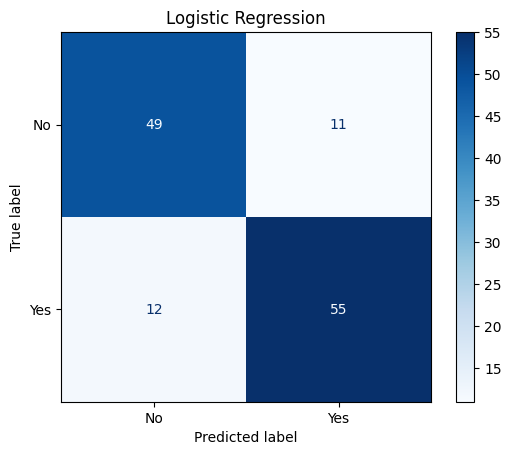

In [348]:
# Predict on test dataset
pred = logistic.predict(X_test)
pred = pred.apply(lambda x: 1 if x>0.5 else 0)

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
cm_display.plot(cmap='Blues')
plt.title('Logistic Regression');

In [349]:
# Get accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
acc

81.89

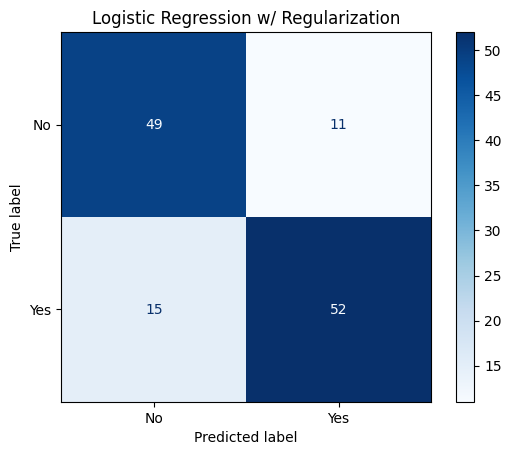

In [350]:
# Logistic Regression with regularization (sklearn package)
logit = LogisticRegression()
logit = logit.fit(X_train, y_train)

# Predict on test dataset
pred = logit.predict(X_test)
pred = np.where(pred > 0.5, 1, 0)

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
cm_display.plot(cmap='Blues')
plt.title('Logistic Regression w/ Regularization');

In [351]:
# Get accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
acc

79.53

After applying some regularization with the second logistic regression, we get a reduction in accuracy when compared to a regular logistic regression.

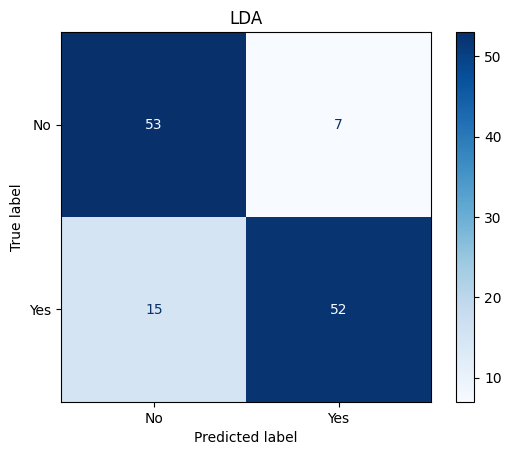

In [352]:
#######
# LDA #
#######
# Create the datasets
X_train.drop(columns='intercept', inplace=True)
X_test.drop(columns='intercept', inplace=True)
"""
obs: LDA automatically adds an intercept
"""

# Create and fit the model
lda = LDA(store_covariance=True)
lda.fit(X_train, y_train)

# Predict
pred = lda.predict(X_test)

# Create and plot a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
cm_display.plot(cmap='Blues')
plt.title('LDA');

In [353]:
# Get accuracy
# Get accuracy and error rate
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
error = round(100 - acc, 2)
print(f"""
LDA acc:   \t{acc}%
""")


LDA acc:   	82.68%



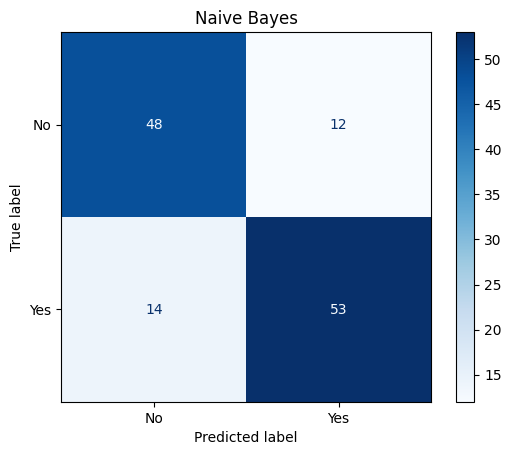

In [354]:
# Create and fit the Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict on the test dataset
pred = nb.predict(X_test)

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
cm_display.plot(cmap='Blues')
plt.title('Naive Bayes');

In [355]:
# Get accuracy and error rate
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
error = round(100 - acc, 2)
print(f"""
Naive Bayes acc:   \t{acc}%
""")


Naive Bayes acc:   	79.53%



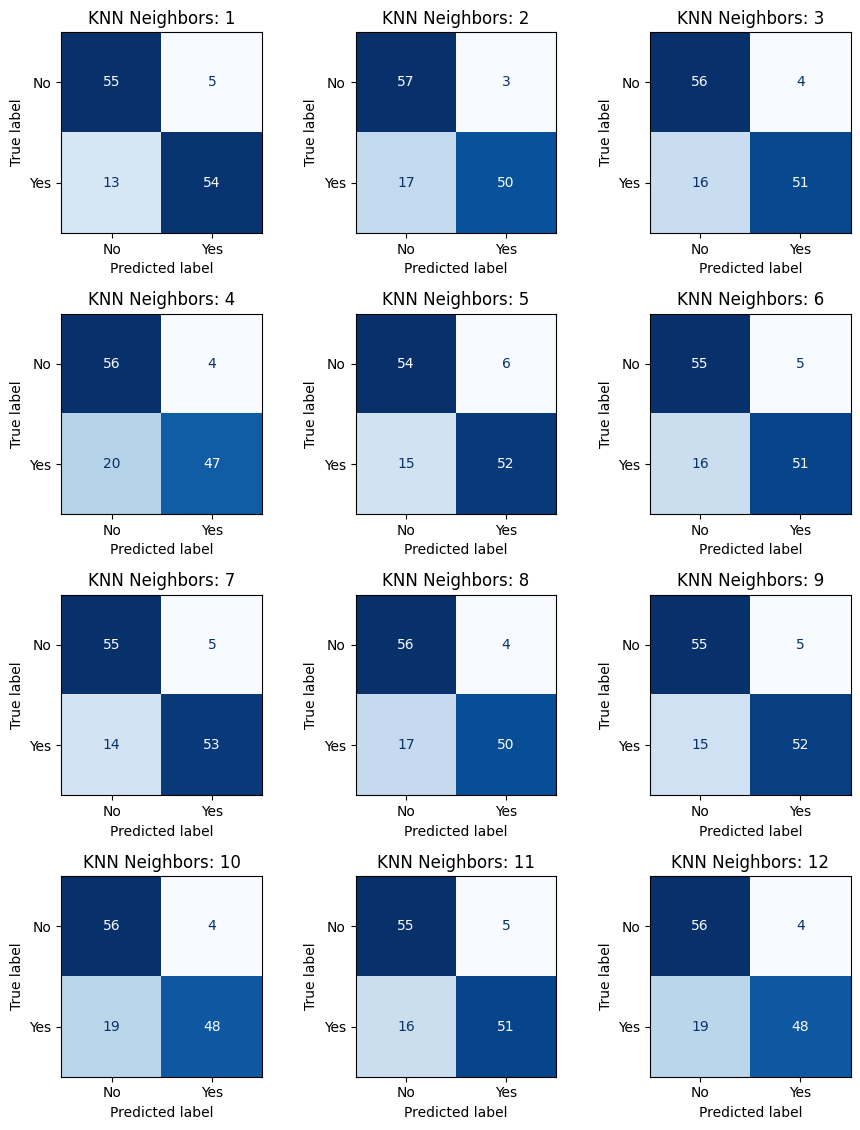

In [356]:
#######
# KNN #
#######
# Standardize features/predictors
columns = ['nox', 'age', 'dis', 'lstat']
scaler = StandardScaler(with_mean=True, with_std=True, copy=True)
scaler.fit(X_train[columns])
X_train_std = scaler.transform(X_train[columns])
X_test_std = scaler.transform(X_test[columns])

# Initialize variables
knn_acc = []
n_neighbors_range = range(1, 13)

# Create a figure and subplots grid
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(9, 12))  # Adjust size as needed
#fig.suptitle('Confusion Matrices for KNN with Varying Neighbors', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through the range of neighbors
for i, ax in enumerate(axes[:len(n_neighbors_range)]):
    # Create and fit the model
    knn = KNN(n_neighbors=n_neighbors_range[i])
    knn.fit(X_train_std, y_train)
    
    # Predict on test dataset & create a confusion matrix
    pred = knn.predict(X_test_std)
    cm = metrics.confusion_matrix(y_test, pred)
    
    # Plot the confusion matrix in the respective subplot
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    cm_display.plot(cmap='Blues', ax=ax, colorbar=False)  # Disable individual colorbars for clarity
    
    ax.set_title(f'KNN Neighbors: {n_neighbors_range[i]}')
    
    # Get the test accuracy and append to list
    acc = round(((cm[0, 0] + cm[1, 1]) / len(y_test)) * 100, 2)
    knn_acc.append(acc)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for suptitle
plt.show()

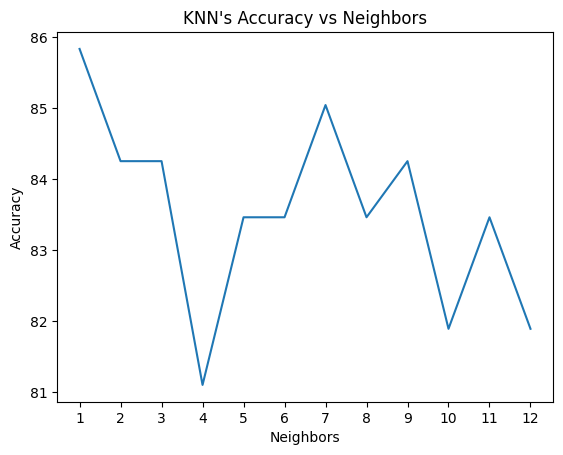

In [357]:
# Plot KNN results
plt.plot(range(1,13), knn_acc)
plt.xticks(range(1,13))
plt.xlabel('Neighbors')
plt.ylabel('Accuracy')
plt.title("KNN's Accuracy vs Neighbors");

In [358]:
print(f"""
KNN max acc: {max(knn_acc)}%
KNN n: {knn_acc.index(max(knn_acc)) + 1}
""")


KNN max acc: 85.83%
KNN n: 1



---

Let's add more features to see if we can improve the models' accuracy.

In [359]:
# Create dummy for 2 highest correlations ('rad', 'tax')
X['rad01'] = boston['rad'].apply(lambda x: 1 if x>20 else 0)
X['tax01'] = boston['tax'].apply(lambda x: 1 if x>600 else 0)

# Split into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [360]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   intercept  506 non-null    float64
 1   nox        506 non-null    float64
 2   age        506 non-null    float64
 3   dis        506 non-null    float64
 4   lstat      506 non-null    float64
 5   rad01      506 non-null    int64  
 6   tax01      506 non-null    int64  
dtypes: float64(5), int64(2)
memory usage: 27.8 KB


In [361]:
# Logistic Regression
logistic = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()
logistic.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                crime01   No. Observations:                  379
Model:                            GLM   Df Residuals:                      372
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -100.61
Date:                Sun, 27 Oct 2024   Deviance:                       201.23
Time:                        15:59:21   Pearson chi2:                     212.
No. Iterations:                    24   Pseudo R-squ. (CS):             0.5747
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -18.1057      3.131     -5.782      0.000     -24.243     -11.968
nox           29.0826      5.369      5.416      0.000      18.559      39.606
age            0.0209      0.011      1.959      0.050   -7.65e-06       0.042
dis            0.3114      0.155      2.003      0.045       0.007       0.616
lstat         -0.0355      0.036     -0.986      0.324      -0.106       0.035
rad01         50.3979   1.26e+05      0.000      1.000   -2.47e+05    2.47e+05
tax01        -27.0151   1.24e+05     -0.000      1.000   -2.44e+05    2.44e+05
==============================================================================
"""

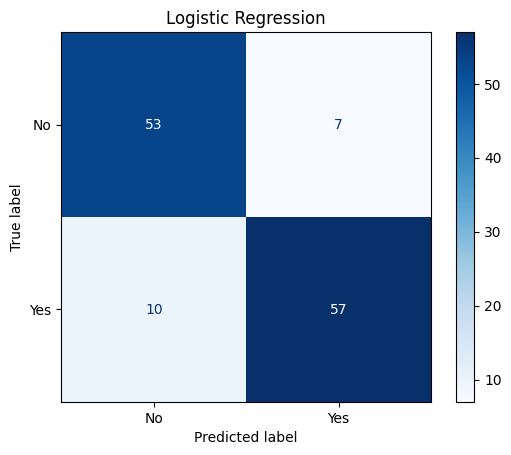

In [362]:
# Predict on test dataset
pred = logistic.predict(X_test)
pred = pred.apply(lambda x: 1 if x>0.5 else 0)

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
cm_display.plot(cmap='Blues')
plt.title('Logistic Regression');

In [363]:
# Get accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
print(f"""
Logistic acc: {acc}%
""")


Logistic acc: 86.61%



/home/andrey/venvs/isl/lib64/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


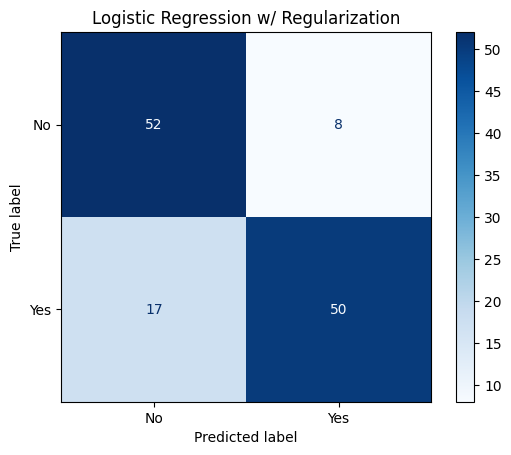

In [364]:
# Logistic Regression with regularization (sklearn package)
logit = LogisticRegression()
logit = logit.fit(X_train, y_train)

# Predict on test dataset
pred = logit.predict(X_test)
pred = np.where(pred > 0.5, 1, 0)

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
cm_display.plot(cmap='Blues')
plt.title('Logistic Regression w/ Regularization');

In [365]:
# Get accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
print(f"""
Logistic acc: {acc}%
""")


Logistic acc: 80.31%



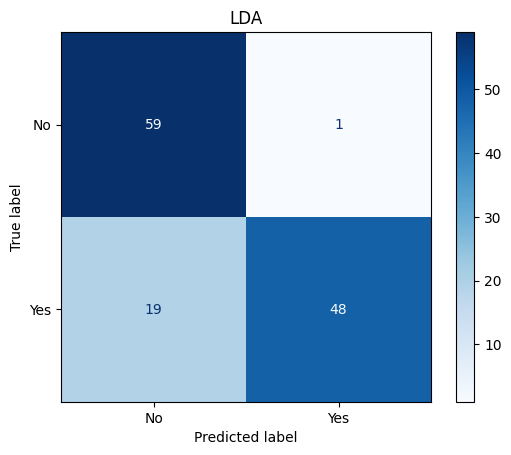

In [366]:
#######
# LDA #
#######
# Create the datasets
X_train.drop(columns='intercept', inplace=True)
X_test.drop(columns='intercept', inplace=True)
"""
obs: LDA automatically adds an intercept
"""

# Create and fit the model
lda = LDA(store_covariance=True)
lda.fit(X_train, y_train)

# Predict
pred = lda.predict(X_test)

# Create and plot a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
cm_display.plot(cmap='Blues')
plt.title('LDA');

In [367]:
# Get accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
print(f"""
LDA acc: {acc}%
""")


LDA acc: 84.25%



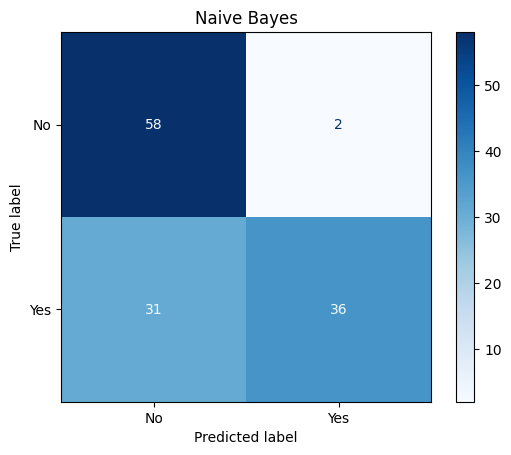

In [368]:
# Create and fit the Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict on the test dataset
pred = nb.predict(X_test)

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
cm_display.plot(cmap='Blues')
plt.title('Naive Bayes');

In [369]:
# Get accuracy
acc = round(((cm[0,0] + cm[1,1]) / len(y_test))*100, 2)
print(f"""
Naive Bayes acc: {acc}%
""")


Naive Bayes acc: 74.02%



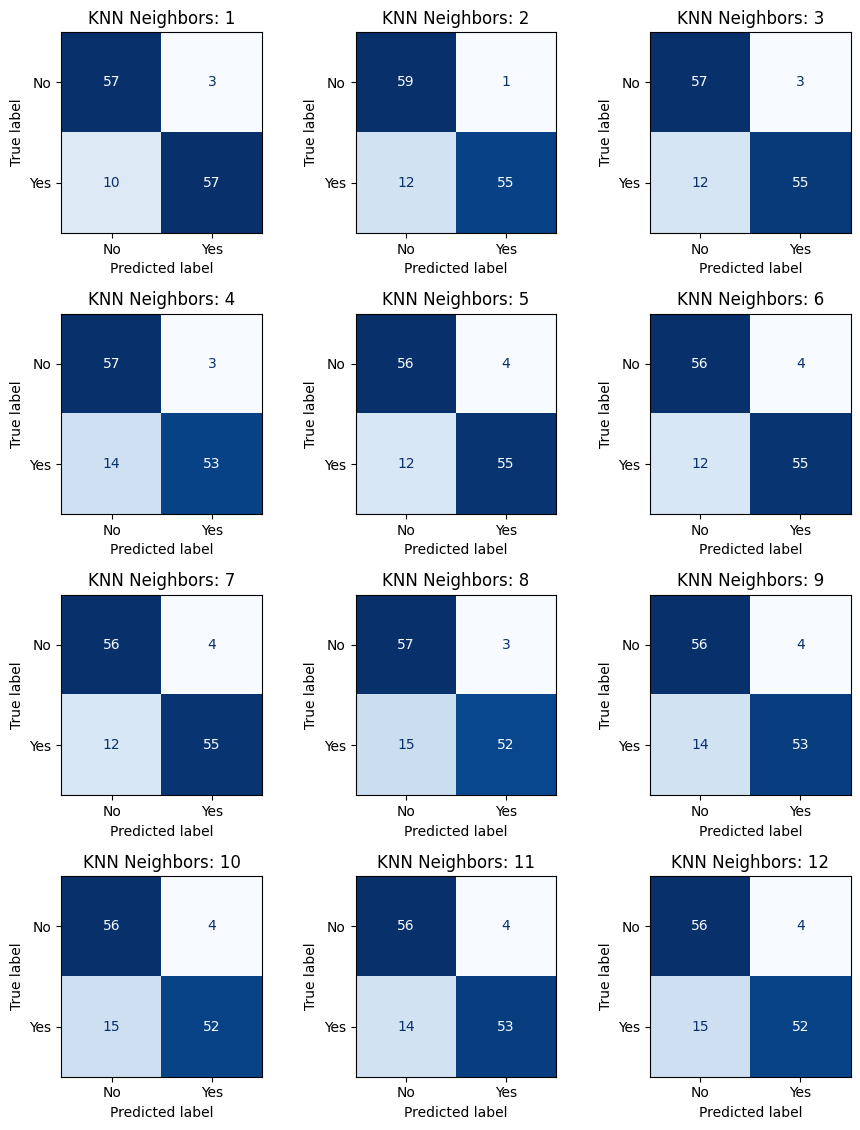

In [370]:
#######
# KNN #
#######
# Standardize features/predictors
columns = ['nox', 'age', 'dis', 'lstat']
scaler = StandardScaler(with_mean=True, with_std=True, copy=True)
scaler.fit(X_train[columns])
X_train_std = scaler.transform(X_train[columns])
X_test_std = scaler.transform(X_test[columns])

# Add dummies
X_train_std = np.concatenate([X_train_std, X_train[['rad01', 'tax01']]], axis=1)
X_test_std = np.concatenate([X_test_std, X_test[['rad01', 'tax01']]], axis=1)

# Initialize variables
knn_acc = []
n_neighbors_range = range(1, 13)

# Create a figure and subplots grid
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(9, 12))  # Adjust size as needed
#fig.suptitle('Confusion Matrices for KNN with Varying Neighbors', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through the range of neighbors
for i, ax in enumerate(axes[:len(n_neighbors_range)]):
    # Create and fit the model
    knn = KNN(n_neighbors=n_neighbors_range[i])
    knn.fit(X_train_std, y_train)
    
    # Predict on test dataset & create a confusion matrix
    pred = knn.predict(X_test_std)
    cm = metrics.confusion_matrix(y_test, pred)
    
    # Plot the confusion matrix in the respective subplot
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    cm_display.plot(cmap='Blues', ax=ax, colorbar=False)  # Disable individual colorbars for clarity
    
    ax.set_title(f'KNN Neighbors: {n_neighbors_range[i]}')
    
    # Get the test accuracy and append to list
    acc = round(((cm[0, 0] + cm[1, 1]) / len(y_test)) * 100, 2)
    knn_acc.append(acc)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for suptitle
plt.show()

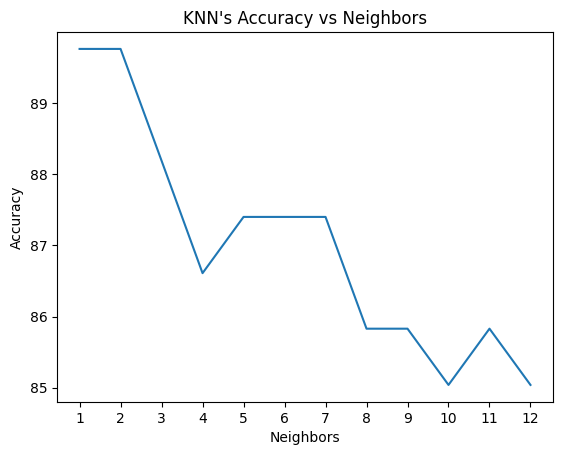

In [371]:
# Plot KNN results
plt.plot(range(1,13), knn_acc)
plt.xticks(range(1,13))
plt.xlabel('Neighbors')
plt.ylabel('Accuracy')
plt.title("KNN's Accuracy vs Neighbors");

In [372]:
print(f"""
KNN max acc: {max(knn_acc)}%
KNN n: {knn_acc.index(max(knn_acc)) + 1}
""")


KNN max acc: 89.76%
KNN n: 1



#### Conclusion

After adding dummy variables for 'rad' and 'tax', we observe an accuracy increase across most models, except for Naive Bayes.

The highest accuracies are from KNN model at 89.76% and Logistic Regression at 86.61%.

Suggested improvements for this exercise include: 1.applying log gransformations to features that disply non-linear relathionships with 'crim'; 2.adding interaction terms and second-order transformations to capture more complex patterns in the dataset.